# LeR model uncertainty example

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com).

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com)

This notebook demonstrates how to propagate source-population hyperparameter uncertainty into **LeR** unlensed and lensed rate predictions. We use posterior samples of the broken powerlaw + two peaks mass model, compare a median-hyperparameter baseline against posterior draws, and visualize the resulting uncertainty in rates and mass distributions.

## Table of Contents

1. [Part 1: Load Hyperparameter Posterior and Inspect Inputs](#part-1-load-hyperparameter-posterior-and-inspect-inputs)
2. [Part 2: Define Baseline Sampler and Initialize LeR](#part-2-define-baseline-sampler-and-initialize-ler)
3. [Part 3: Median-Hyperparameter Baseline Run](#part-3-median-hyperparameter-baseline-run)
4. [Part 4: Posterior Propagation Across Hyperparameter Draws](#part-4-posterior-propagation-across-hyperparameter-draws)
5. [Part 5: Visualize Uncertainty in Rates and Mass Distribution](#part-5-visualize-uncertainty-in-rates-and-mass-distribution)
6. [Summary](#summary)

---

## Part 1: Load Hyperparameter Posterior and Inspect Inputs

### 1.1 Load Posterior Samples of Mass Model Hyperparameters

- This data is resampled from the original GWTC-4 posterior, within the 90% credible interval, to reduce runtime for this example. 

In [14]:
# load data 
from ler.utils import get_param_from_json
import numpy as np

# 500 samples from the 90% credible interval of the hyperparameters of the broken powerlaw plus 2 peaks model from GWTC-4
data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")
# data

# # plot the corner plot of the hyperparameters
# from corner import corner
# labels = list(data.keys())
# # use column stacks
# data_ = np.column_stack([data[key] for key in labels])

# figure = corner(data_, labels=labels, show_titles=True)

In [18]:
data["alpha_1"].max()

np.float64(2.8611918415613653)

In [8]:
loop_size = 100
lam_0_median=np.median(data["lam_0"])
lam_1_median=np.median(data["lam_1"])
mpp_1_median=np.median(data["mpp_1"])
sigpp_1_median=np.median(data["sigpp_1"])
mpp_2_median=np.median(data["mpp_2"])
sigpp_2_median=np.median(data["sigpp_2"])
mlow_1_median=np.median(data["mlow_1"])
delta_m_1_median=np.median(data["delta_m_1"])
break_mass_median=np.median(data["break_mass"])   
alpha_1_median=np.median(data["alpha_1"])
alpha_2_median=np.median(data["alpha_2"])

idx = np.random.choice(len(data["lam_0"]), size=loop_size, replace=False)
lam_0 = data["lam_0"][idx]
lam_1 = data["lam_1"][idx]
mpp_1 = data["mpp_1"][idx]
sigpp_1 = data["sigpp_1"][idx]
mpp_2 = data["mpp_2"][idx]
sigpp_2 = data["sigpp_2"][idx]
mlow_1 = data["mlow_1"][idx]
delta_m_1 = data["delta_m_1"][idx]
break_mass = data["break_mass"][idx]
alpha_1 = data["alpha_1"][idx]
alpha_2 = data["alpha_2"][idx]

## Velocity Dispersion

Ref. Bernardi et al. (2024)

![image.png](attachment:image.png)

In [9]:
alpha = np.random.uniform(0.94-0.03, 0.94+0.03, size=loop_size)
beta = np.random.uniform(1.85-0.02, 1.85+0.02, size=loop_size)
phistar = np.random.uniform(2.099-0.099, 2.099+0.099, size=loop_size)
sigmastar = np.random.uniform(113.78-1.06, 113.78+1.06, size=loop_size)

alpha_median=0.94
beta_median=1.85
phistar_median=2.099
sigmastar_median=113.78   

## Merger Rate Denisity

In [10]:
# load data 
from ler.utils import get_param_from_json
import numpy as np

# 500 samples from the 90% credible interval of the hyperparameters of the powerlaw redshift model from GWTC-4
data = get_param_from_json("powerlaw_redshift_hyperparameters.json")
# data

# # plot the corner plot of the hyperparameters
# from corner import corner
# labels = list(data.keys())
# # use column stacks
# data_ = np.column_stack([data[key] for key in labels])

# figure = corner(data_, labels=labels, show_titles=True)

In [11]:
R0_median=np.median(data["R0"])
# kappa_median=np.median(data["kappa"])

idx = np.random.choice(len(data["R0"]), size=loop_size, replace=False)
R0 = data["R0"][idx]
# kappa = data["kappa"][idx]  

In [12]:
R0_median

np.float64(16.026789818545016)

## Cosmology

Planck 2018 LambdaCDM cosmology is used for all calculations in this example.

![image.png](attachment:image.png)

In [6]:
import numpy as np
import astropy.units as u

# Base static parameters (typically kept constant across base LCDM models)
Tcmb0 = 2.7255  # K
Neff = 3.046
m_nu = [0.0, 0.0, 0.06] * u.eV  # Minimal mass sum scenario

H0_median = 67.4
Om0_median = 0.315
Ob0_median = 0.0493

H0 = np.random.uniform(67.66-0.42, 67.66+0.42, size=loop_size)
Om0 = np.random.uniform(0.3111-0.0056, 0.3111+0.0056, size=loop_size)
Ob0 = np.random.uniform(0.04897-0.00030, 0.04897+0.00030, size=loop_size)

---

## Part 2: Define Baseline Sampler and Initialize LeR

### 2.1 Median-hyperparameter mass sampler

Define a mass sampler with fixed median hyperparameters. This provides a consistent baseline model for comparison with posterior-propagated runs.

### 2.2 Initialize LeR

Instantiate LeR with the custom median-hyperparameter mass prior and default BBH lensing settings.

In [7]:
import numpy as np
from ler import LeR
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=H0_median, Om0=Om0_median, Ob0=Ob0_median, Tcmb0=Tcmb0, Neff=Neff, m_nu=m_nu)

ler = LeR(
    npool=6,
    cosmo=cosmo,
    event_type="BBH",
    lens_type="sie_galaxy",
    verbose=False,
    gwsnr_verbose=False,
    image_properties_function="image_properties_epl_shear_njit",
    gw_functions=dict(
        merger_rate_density='merger_rate_density_madau_dickinson_belczynski_ng',
    ),
    gw_functions_params=dict(
        merger_rate_density=dict(
            param_name="merger_rate_density",
            function_type="merger_rate_density_madau_dickinson_belczynski_ng",
            R0=R0_median * 1e-9, alpha_F=2.57, beta_F=5.83, c_F=3.36
        ),
    ),
    gw_priors=dict(
        mass_1_source='broken_powerlaw_plus_2peaks'
    ),
    gw_priors_params=dict(
        mass_1_source=dict(
            param_name="mass_1_source",
            function_type="broken_powerlaw_plus_2peaks",
            lam_0=lam_0_median, lam_1=lam_1_median, mpp_1=mpp_1_median, sigpp_1=sigpp_1_median, mpp_2=mpp_2_median, sigpp_2=sigpp_2_median, mlow_1=mlow_1_median, delta_m_1=delta_m_1_median, break_mass=break_mass_median, alpha_1=alpha_1_median, alpha_2=alpha_2_median, 
            mmax=300.0, normalization_size=500,
        ),
    ),
    lens_priors=dict(
        velocity_dispersion='velocity_dispersion_ewoud',
    ),
    lens_priors_params=dict(
        velocity_dispersion=dict(
            param_name="velocity_dispersion",
            sampler_type="velocity_dispersion_ewoud",
            sigma_min=100.0,
            sigma_max=400.0,
            alpha=alpha_median,
            beta=beta_median,
            phistar=phistar_median * 1e-2 * (cosmo.h/0.7)**3,
            sigmastar=sigmastar_median,
        ),
    ),
)
# 1.6s


Initializing LeR class...



---

## Part 3: Median-Hyperparameter Baseline Run

Compute unlensed and lensed rates with the median hyperparameter model. This serves as the reference point for uncertainty comparisons.

### 3.1 Generate CBC populations and rates

Run one unlensed and one lensed simulation, then compute the rate ratio for the baseline model.

In [ ]:
from contextlib import redirect_stdout
from ler.utils import relative_mu_dt_lensed

sample_size = 500000
batch_size = 50000
size_ = 10000

# unlensed rates
unlensed_params = ler.unlensed_cbc_statistics(size=sample_size, batch_size=batch_size, resume=False, output_jsonfile="median_unlensed.json")
unlensed_rate_median, unlensed_params_det = ler.unlensed_rate(unlensed_params, output_jsonfile="median_unlensed_det.json")

# lensed rates
lensed_params = ler.lensed_cbc_statistics(size=sample_size, batch_size=batch_size, resume=False, output_jsonfile="median_lensed.json")
lensed_rate_median, lensed_params_det = ler.lensed_rate(lensed_params, output_jsonfile="median_lensed_det.json")
rate_ratio_median = unlensed_rate_median / lensed_rate_median
# time: 2m 24.1s

unlensed params will be stored in ./ler_data/median_unlensed.json
removing ./ler_data/median_unlensed.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
unlensed parameters already sampled.
Using provided unlensed_param dict...
total unlensed rate (yr^-1): 287.99670176824714
number of simulated unlensed detectable events: 1864
number of simulated all unlensed events: 500000
storing detectable params in ./ler_data/median_unlensed_det.json
lensed params will be stored in ./ler_data/median_lensed.json
removing ./ler_data/median_lensed.json if it exists
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 32485 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 2091 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 132 lensed events...
sampling lens parameters with 

In [9]:
m1_source_samples_median = np.random.choice(unlensed_params["mass_1_source"], size=size_, replace=False)
zs_samples_median = np.random.choice(unlensed_params["zs"], size=size_, replace=False)

velocity_dispersion_samples_sl_median = np.random.choice(lensed_params["sigma"], size=size_, replace=False)

zs = np.linspace(0, 10, 100)
optical_depth_samples_sl_median = ler.optical_depth(zs)

zs_samples_det_median = unlensed_params_det["zs"]
m1_samples_det_median = unlensed_params_det["mass_1"]

zs_samples_sl_det_median = lensed_params_det["zs"]
m1_samples_sl_det_median = lensed_params_det["mass_1"]
lensed_dict = relative_mu_dt_lensed(lensed_param=lensed_params_det)
time_delays_sl_det_median = np.concatenate((lensed_dict['dt_rel0'], lensed_dict['dt_rel90']))

print(f"Unlensed rate: {unlensed_rate_median:.3f} per year")
print(f"Lensed rate: {lensed_rate_median:.3f} per year")
# rate ratio
print(f"Rate ratio (lensed/unlensed): {rate_ratio_median:.3f}")

Unlensed rate: 287.997 per year
Lensed rate: 0.082 per year
Rate ratio (lensed/unlensed): 3503.502


---

## Part 4: Posterior Propagation Across Hyperparameter Draws

Sample multiple hyperparameter realizations from the posterior and recompute unlensed/lensed rates for each draw.

### 4.1 Loop over posterior samples

For each selected posterior sample, reconfigure the mass sampler, run LeR statistics, and store rates and mass samples for uncertainty analysis.

In [17]:
# from ler.utils import relative_mu_dt_lensed
# import numpy as np
# from ler import LeR
# from astropy.cosmology import FlatLambdaCDM
# from contextlib import redirect_stdout


# cosmo = FlatLambdaCDM(H0=H0_median, Om0=Om0_median, Ob0=Ob0_median, Tcmb0=Tcmb0, Neff=Neff, m_nu=m_nu)

# sample_size = 500000
# batch_size = 50000
# loop_size = 100

# size_ = 10000
# m1_source_samples = []
# zs_samples = []

# velocity_dispersion_samples_sl = []
# optical_depth_samples_sl = []

# zs_samples_det = []
# m1_samples_det = []

# zs_samples_sl_det = []
# m1_samples_sl_det = []
# time_delays_sl_det = []

# unlensed_rates = []
# lensed_rates = []
# rate_ratios = []

# from tqdm import tqdm

# for i in tqdm(range(loop_size), total=loop_size, ncols=100):
#     with redirect_stdout(None):

#         cosmo = FlatLambdaCDM(H0=H0[i], Om0=Om0[i], Ob0=Ob0[i], Tcmb0=Tcmb0, Neff=Neff, m_nu=m_nu)

#         ler = LeR(
#             npool=6,
#             cosmo=cosmo,
#             event_type="BBH",
#             lens_type="sie_galaxy",
#             image_properties_function="image_properties_epl_shear_njit",
#             verbose=False,
#             gwsnr_verbose=False,

#             gw_functions=dict(
#                 merger_rate_density='merger_rate_density_madau_dickinson_belczynski_ng',
#             ),
#             gw_functions_params=dict(
#                 merger_rate_density=dict(
#                     param_name="merger_rate_density",
#                     function_type="merger_rate_density_madau_dickinson_belczynski_ng",
#                     R0=R0[i] * 1e-9, alpha_F=2.57, beta_F=5.83, c_F=3.36
#                 ),
#             ),
#             gw_priors=dict(
#                 mass_1_source='broken_powerlaw_plus_2peaks'
#             ),
#             gw_priors_params=dict(
#                 mass_1_source=dict(
#                     param_name="mass_1_source",
#                     function_type="broken_powerlaw_plus_2peaks",
#                     lam_0=lam_0[i], lam_1=lam_1[i], mpp_1=mpp_1[i], sigpp_1=sigpp_1[i], mpp_2=mpp_2[i], sigpp_2=sigpp_2[i], mlow_1=mlow_1[i], delta_m_1=delta_m_1[i], break_mass=break_mass[i], alpha_1=alpha_1[i], alpha_2=alpha_2[i], 
#                     mmax=300.0, normalization_size=500,
#                 ),
#             ),
#             lens_priors=dict(
#                 velocity_dispersion='velocity_dispersion_ewoud',
#             ),
#             lens_priors_params=dict(
#                 velocity_dispersion=dict(
#                     param_name="velocity_dispersion",
#                     sampler_type="velocity_dispersion_ewoud",
#                     sigma_min=100.0,
#                     sigma_max=400.0,
#                     alpha=alpha[i],
#                     beta=beta[i],
#                     phistar=phistar[i] * 1e-2 * (cosmo.h/0.7)**3,
#                     sigmastar=sigmastar[i],
#                 ),
#             ),
#         )

#         # unlensed rates
#         unlensed_params = ler.unlensed_cbc_statistics(size=sample_size, batch_size=batch_size, resume=False, output_jsonfile=False)
#         unlensed_rate, unlensed_params_det = ler.unlensed_rate(unlensed_params, output_jsonfile=False)
#         # lensed rates
#         lensed_params = ler.lensed_cbc_statistics(size=sample_size, batch_size=batch_size, resume=False, output_jsonfile=False)
#         lensed_rate, lensed_params_det = ler.lensed_rate(lensed_params, output_jsonfile=False)
#         rate_ratio = unlensed_rate / lensed_rate

#         m1_source_samples.append(np.random.choice(unlensed_params["mass_1_source"], size=size_, replace=False))
#         zs_samples.append(np.random.choice(unlensed_params["zs"], size=size_, replace=False))

#         velocity_dispersion_samples_sl.append(np.random.choice(lensed_params["sigma"], size=size_, replace=False))

#         zs = np.linspace(0, 10, 100)
#         optical_depth_samples_sl.append(ler.optical_depth(zs))

#         zs_samples_det.append(unlensed_params_det["zs"])
#         m1_samples_det.append(unlensed_params_det["mass_1"])

#         zs_samples_sl_det.append(lensed_params_det["zs"])
#         m1_samples_sl_det.append(lensed_params_det["mass_1"])
#         lensed_dict = relative_mu_dt_lensed(lensed_param=lensed_params_det)
#         time_delays_sl_det.append(np.concatenate((lensed_dict['dt_rel0'], lensed_dict['dt_rel90'])))

#         unlensed_rates.append(unlensed_rate)
#         lensed_rates.append(lensed_rate)
#         rate_ratios.append(rate_ratio)

# # detectable numbers doesn't need to have the same number of samples
# m1_source_samples = np.array(m1_source_samples, dtype=object)
# zs_samples = np.array(zs_samples, dtype=object)
# velocity_dispersion_samples_sl = np.array(velocity_dispersion_samples_sl, dtype=object)
# optical_depth_samples_sl = np.array(optical_depth_samples_sl, dtype=object)
# zs_samples_det = np.array(zs_samples_det, dtype=object)
# m1_samples_det = np.array(m1_samples_det, dtype=object)
# zs_samples_sl_det = np.array(zs_samples_sl_det, dtype=object)
# m1_samples_sl_det = np.array(m1_samples_sl_det, dtype=object)
# time_delays_sl_det = np.array(time_delays_sl_det, dtype=object) 
# unlensed_rates = np.array(unlensed_rates)
# lensed_rates = np.array(lensed_rates)
# rate_ratios = np.array(rate_ratios)
# # time: 2.44min * loop_size
# # time: 5m 29.2s for loop_size=2
# # loop_size=100 would take around 4 hours

### 4.2 Save and reload propagated results

Use JSON persistence for reproducibility and faster reruns of plotting sections without recomputing expensive simulations.

In [10]:
# # save the results in a json file
# from ler.utils import append_json
# dict_ = dict(
#     m1_source_samples=m1_source_samples,
#     zs_samples=zs_samples,
#     velocity_dispersion_samples_sl=velocity_dispersion_samples_sl,
#     optical_depth_samples_sl=optical_depth_samples_sl,
#     zs_samples_det=zs_samples_det,
#     m1_samples_det=m1_samples_det,
#     zs_samples_sl_det=zs_samples_sl_det,
#     m1_samples_sl_det=m1_samples_sl_det,
#     time_delays_sl_det=time_delays_sl_det,
#     unlensed_rates=unlensed_rates,
#     lensed_rates=lensed_rates,
#     rate_ratios=rate_ratios,
#     # median 
#     m1_source_samples_median=m1_source_samples_median,
#     zs_samples_median=zs_samples_median,
#     velocity_dispersion_samples_sl_median=velocity_dispersion_samples_sl_median,
#     optical_depth_samples_sl_median=optical_depth_samples_sl_median,
#     zs_samples_det_median=zs_samples_det_median,
#     m1_samples_det_median=m1_samples_det_median,
#     zs_samples_sl_det_median=zs_samples_sl_det_median,
#     m1_samples_sl_det_median=m1_samples_sl_det_median,
#     time_delays_sl_det_median=time_delays_sl_det_median,
#     unlensed_rate_median=unlensed_rate_median,
#     lensed_rate_median=lensed_rate_median,
#     rate_ratio_median=rate_ratio_median,
# )
# # save the results in a json file
# append_json("LeR_model_uncertainty.json", dict_, replace=True);

from ler.utils import load_json

results = load_json("LeR_model_uncertainty.json")
m1_source_samples = results["m1_source_samples"]
zs_samples = results["zs_samples"]
velocity_dispersion_samples_sl = results["velocity_dispersion_samples_sl"]
optical_depth_samples_sl = results["optical_depth_samples_sl"]
zs_samples_det = results["zs_samples_det"]
m1_samples_det = results["m1_samples_det"]
zs_samples_sl_det = results["zs_samples_sl_det"]
m1_samples_sl_det = results["m1_samples_sl_det"]
time_delays_sl_det = results["time_delays_sl_det"]
unlensed_rates = results["unlensed_rates"]
lensed_rates = results["lensed_rates"]
rate_ratios = results["rate_ratios"]
# median 
m1_source_samples_median = results["m1_source_samples_median"]
zs_samples_median = results["zs_samples_median"]
velocity_dispersion_samples_sl_median = results["velocity_dispersion_samples_sl_median"]
optical_depth_samples_sl_median = results["optical_depth_samples_sl_median"]
zs_samples_det_median = results["zs_samples_det_median"]
m1_samples_det_median = results["m1_samples_det_median"]
zs_samples_sl_det_median = results["zs_samples_sl_det_median"]
m1_samples_sl_det_median = results["m1_samples_sl_det_median"]
time_delays_sl_det_median = results["time_delays_sl_det_median"]
unlensed_rate_median = results["unlensed_rate_median"]
lensed_rate_median = results["lensed_rate_median"]
rate_ratio_median = results["rate_ratio_median"]

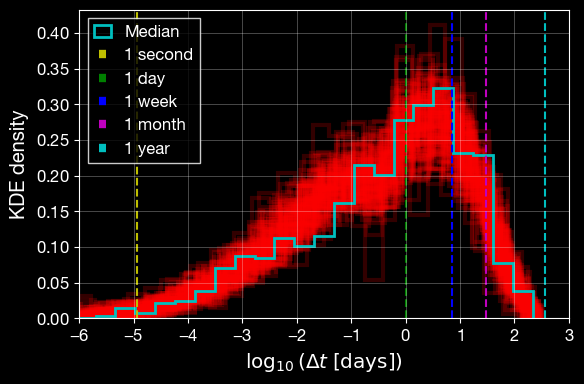

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.figure(figsize=(6, 4))

for i in range(len(time_delays_sl_det)):
    plt.hist(np.log10(time_delays_sl_det[i]), bins=30, alpha=0.2, density=True, color='r', linewidth=3, histtype='step')

# median time delays
plt.hist(np.log10(time_delays_sl_det_median), bins=30, alpha=1.0, density=True, color='c', linewidth=2, label="Median", histtype='step')

# vertical line for 1s, 1day, 1 week, 1 month, 1 year
plt.axvline(np.log10(1/86400), color='y', linestyle='--', label='1 second')
plt.axvline(np.log10(1), color='g', linestyle='--', label='1 day')
plt.axvline(np.log10(7), color='b', linestyle='--', label='1 week')
plt.axvline(np.log10(30), color='m', linestyle='--', label='1 month')
plt.axvline(np.log10(365), color='c', linestyle='--', label='1 year')

plt.xlim(-6, 3)
plt.xlabel(r"$\log_{10}(\Delta t\;[\mathrm{days}])$")
plt.ylabel("KDE density")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()


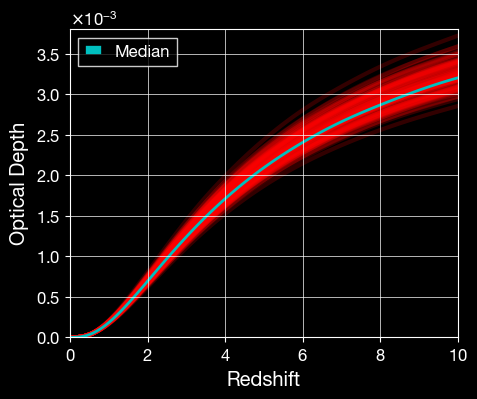

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
zs = np.linspace(0, 10, 100)
for j in range(loop_size):
    plt.plot(zs, optical_depth_samples_sl[j], color='r', alpha=0.2, linewidth=3)

# median optical depth
plt.plot(zs, optical_depth_samples_sl_median, color='c', alpha=1.0, linewidth=2, label="Median")

plt.xlim(0, 10)
plt.ylim(0, 3.8e-3)
plt.xlabel("Redshift")
plt.ylabel("Optical Depth")
plt.legend()
plt.show()

<!-- ### 4.2 Prior reweighting 

Instead of the slow loop which requires reconfiguring the mass sampler and rerunning the statistics for each posterior sample, we can use prior reweighting to estimate the rates for different hyperparameter values. This approach is much faster and allows us to explore a larger number of posterior samples.

$$ 
\begin{split}
\frac{\Delta N^{\rm obs}_{\rm U}}{\Delta t} = \frac{\Delta N_{\rm U}}{\Delta t} \int P({\rm obs} \mid \vec{\theta})\, P_{\rm old}(\vec{\theta})\, d\vec{\theta} \\
\approx \frac{\Delta N_{\rm U}}{\Delta t} \frac{1}{N} \sum_{i=1}^N P({\rm obs} \mid \vec{\theta}_i) \frac{P_{\rm new}(\vec{\theta}_i)}{P_{\rm old}(\vec{\theta}_i)} \, ,
\end{split}
$$

where the $\vec{\theta}_i$ are samples drawn from the original prior $P_{\rm old}$.  -->


---

## Part 5: Visualize Uncertainty in Rates and Mass Distribution

### 5.1 Rate distributions

Compare baseline (median) rates against the posterior-propagated distribution for unlensed rates, lensed rates, and their ratio.

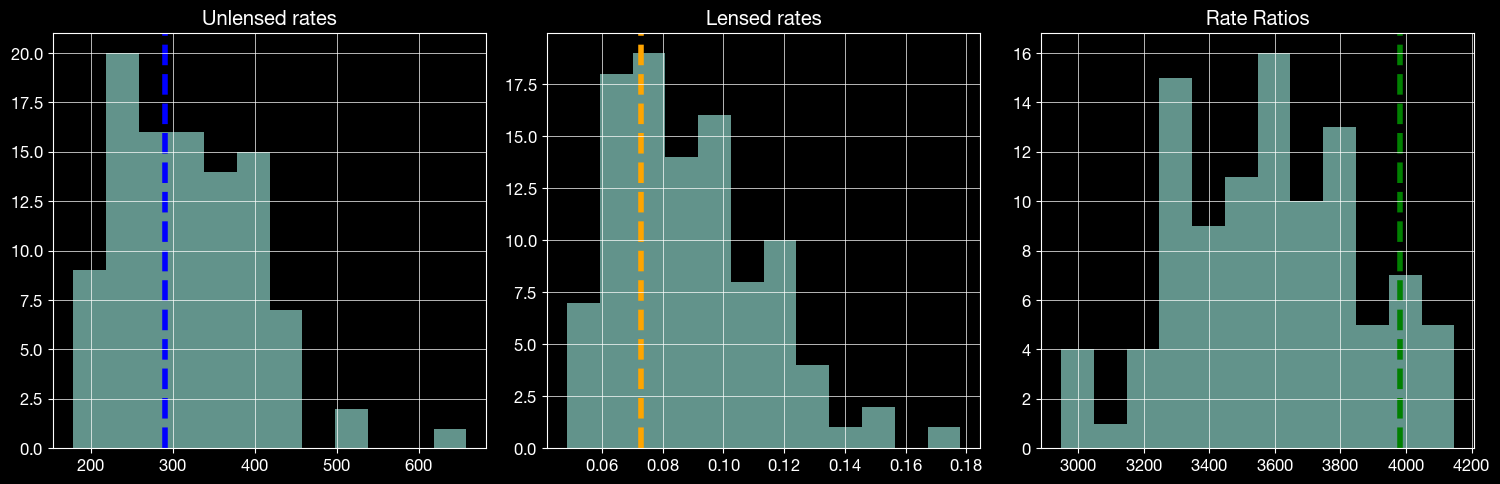

In [32]:
# plot the distribution of the rates and rate ratios
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.hist(unlensed_rates, bins=12, alpha=0.7)
# median value
ax1.axvline(unlensed_rate_median, color="blue", linestyle="--", linewidth=4)
ax1.set_title("Unlensed rates")

ax2.hist(lensed_rates, bins=12, alpha=0.7)
ax2.axvline(lensed_rate_median, color="orange", linestyle="--", linewidth=4)
ax2.set_title("Lensed rates")

ax3.hist(rate_ratios, bins=12, alpha=0.7)
ax3.axvline(rate_ratio_median, color="green", linestyle="--", linewidth=4)
ax3.set_title("Rate Ratios")

plt.tight_layout()
plt.show()

### 5.2 Source-mass distribution uncertainty

Overlay mass distributions from posterior realizations and compare against the median-hyperparameter reference distribution.

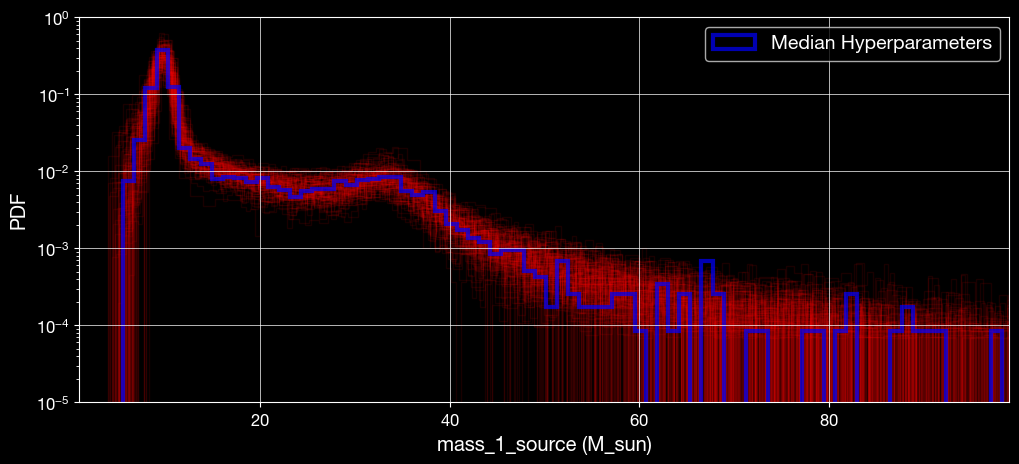

In [ ]:
# Plot m1 distribution overlays using m1_samples_unlensed
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
bins = 200
# Plot many recalibrated sample histograms and their corresponding PDF estimates
for arr in m1_source_samples:
    plt.hist(arr, bins=bins, density=True, alpha=0.1, color='r', histtype='step')

plt.hist(m1_source_samples_median, bins=bins, density=True, alpha=0.7, color='blue', histtype='step', label='Median Hyperparameters', linewidth=3)

legend = plt.legend(
    handlelength=2.2,
    loc='upper right',
    bbox_to_anchor=(1, 1),
    frameon=True,
    fontsize=14,
    edgecolor='lightgray'
)
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
for handle in legend.get_lines():
    handle.set_linewidth(1.6)
    handle.set_alpha(0.85)

plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.xlim(1, 99)
plt.xlabel('mass_1_source (M_sun)')
plt.ylabel('PDF')
plt.show()

---

## Summary

This notebook demonstrated how to propagate astrophysical mass-model uncertainty into LeR rate predictions.

1. Loaded posterior samples for the broken powerlaw + two peaks hyperparameters.
2. Built a median-hyperparameter baseline and computed unlensed/lensed rates.
3. Propagated posterior uncertainty through repeated LeR simulations.
4. Compared the baseline against posterior-driven distributions of rates and source masses.

This workflow provides uncertainty-aware rate estimates rather than a single deterministic rate value.